In [21]:
# Used Car Price Prediction with Linear Models

Comparison of Linear Regression, Ridge and Lasso for used-car
price prediction, using leakage-safe preprocessing and cross-validation.


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn import set_config
import matplotlib.pyplot as plt
import os

   make_year  mileage_kmpl  engine_cc fuel_type  owner_count  price_usd  \
0       2001          8.17       4000    Petrol            4    8587.64   
1       2014         17.59       1500    Petrol            4    5943.50   
2       2023         18.09       2500    Diesel            5    9273.58   
3       2009         11.28        800    Petrol            1    6836.24   
4       2005         12.23       1000    Petrol            2    4625.79   

       brand transmission  color service_history  accidents_reported  \
0  Chevrolet       Manual  White             NaN                   0   
1      Honda       Manual  Black             NaN                   0   
2        BMW    Automatic  Black            Full                   1   
3    Hyundai       Manual   Blue            Full                   0   
4     Nissan    Automatic    Red            Full                   0   

  insurance_valid  
0              No  
1             Yes  
2             Yes  
3             Yes  
4             Ye

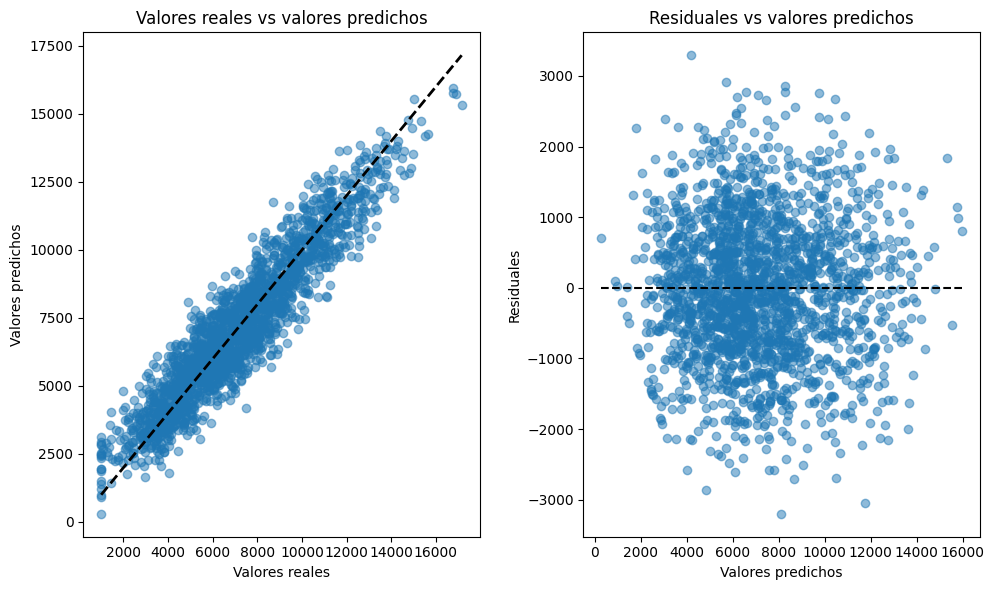

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params lasso: {'regressor__alpha': 5}
   param_regressor__alpha  mean_test_score  rank_test_score
0                     0.1    -1.011452e+06                5
1                     0.5    -1.011265e+06                4
2                     1.0    -1.011108e+06                3
3                     5.0    -1.009499e+06                1
4                    10.0    -1.009720e+06                2
R2 Score Lasso: 0.876486540490299
MAE Lasso: 791.8905330323278
RMSE Lasso: 991.2689235694412
   param_regressor__alpha      CV_RMSE  rank_test_score
0                     0.1  1005.709857                5
1                     0.5  1005.616662                4
2                     1.0  1005.538507                3
3                     5.0  1004.738056                1
4                    10.0  1004.848270                2


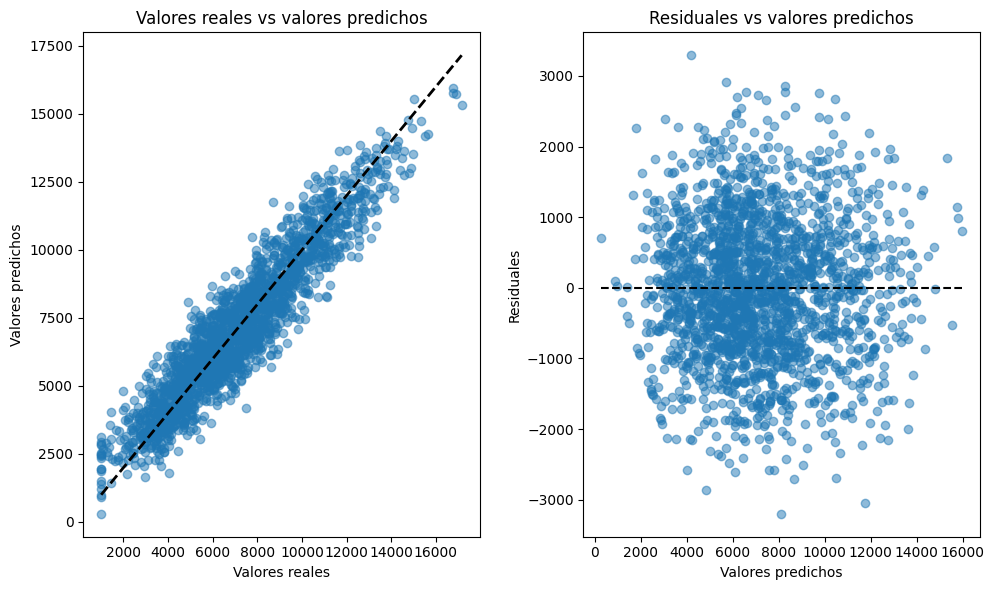

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params ridge {'regressor__alpha': 1}
R2 Score Ridge: 0.8765442040527032
MAE Ridge: 791.0298751901726
RMSE Ridge: 991.0375043756662
   param_regressor__alpha      CV_RMSE  rank_test_score
0                    0.01  1005.737327                4
1                    0.10  1005.736910                3
2                    0.50  1005.735360                2
3                    1.00  1005.734118                1
4                    5.00  1005.751345                5
5                   10.00  1005.837869                6


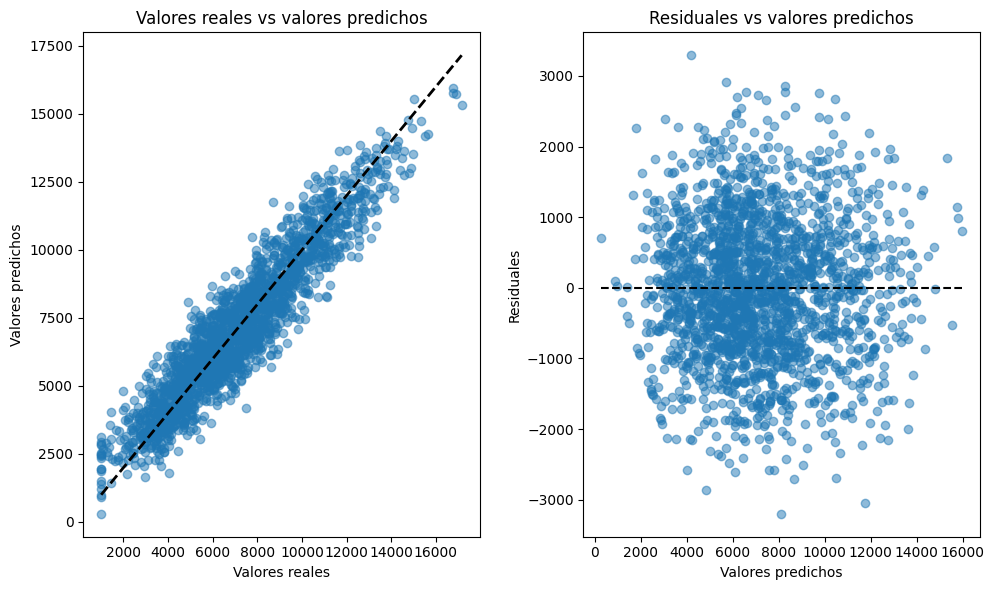

R2 Score Ridge: 0.8765442040527032
R2 Score Lasso: 0.876486540490299
R2 Score LinReg: 0.8765494410543438
                         Feature       Linear        Ridge        Lasso
0                 num__make_year  1247.665688  1247.485043  1242.492929
1              num__mileage_kmpl   606.045905   605.970711   601.169252
2                 num__engine_cc  1927.249082  1926.977638  1921.703158
3               num__owner_count  -694.364821  -694.295979  -690.022719
4        num__accidents_reported     3.174588     3.188802     0.000000
5        cat__fuel_type_Electric  3013.834928  3009.087016  2961.266594
6          cat__fuel_type_Petrol    -4.071793    -5.016804    -0.000000
7           cat__brand_Chevrolet   -80.604284   -79.757959    -0.000000
8                cat__brand_Ford   -81.393939   -80.471107    -0.000000
9               cat__brand_Honda   -42.112574   -41.275036     0.000000
10            cat__brand_Hyundai   -89.777313   -88.955060    -0.000000
11                cat__brand_Ki

In [22]:
df = pd.read_csv('data/used_car_price_dataset_extended.csv')

def plot_results(y_test, y_pred):
  plt.figure(figsize=(10, 6))
  plt.subplot(1,2,1)
  plt.scatter(y_test, y_pred, alpha = 0.5)
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw = 2)
  plt.xlabel('Valores reales')
  plt.ylabel('Valores predichos')
  plt.title('Valores reales vs valores predichos')

  plt.subplot(1,2,2)
  residuales = y_test - y_pred
  plt.scatter(y_pred, residuales, alpha = 0.5)
  plt.hlines(y = 0, xmin= y_pred.min(), xmax = y_pred.max(), colors = 'k', linestyles = 'dashed')
  plt.xlabel('Valores predichos')
  plt.ylabel('Residuales')
  plt.title('Residuales vs valores predichos')
  plt.tight_layout()
  plt.show()
############### Paso 1: Revision de los datos
print(df.head())
print(df.info())
print(df.isnull().sum())

#Grafico de los datos

############## Paso 2: Preprocesamiento de datos (limpia de datos, feature engineering, normalizacion, separacion de datos test/train)

#Rellenar valores vacios
print(df["service_history"].unique())

###Caso de los objetos / String

#Reemplazo del valor NaN
df['service_history'] = df["service_history"].fillna("Unknown") #Columna especifica
print(df["service_history"].value_counts(dropna=False))

###Separacion de los datos

X = df.drop(['price_usd'], axis = 1) #Seleccion de las caracteristicas
y = df['price_usd'] #Seleccion del target

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

##Categorias = Text, Numericos

num_cols = X.select_dtypes(exclude = 'object').columns
cat_cols = X.select_dtypes(include='object').columns

#Normalizacion de variable numerica
scaler = StandardScaler()
#Normalizacion de variable categorica
encoder = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    [
        ('num', scaler, num_cols), ('cat', encoder, cat_cols)
    ]
)

####################### Paso 3: Entrenamiento del modelo (Declarar el modelo, Buscar los mejores parametros, entrenamiento, score)

####################### Paso 3.1 Linear Regresion Baseline

lin_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

#Entrenamiento
lin_reg_pipeline.fit(X_train, y_train)

#Prediccion
y_pred = lin_reg_pipeline.predict(X_test)

##Score

#R2 Score
R2score = r2_score(y_test, y_pred)
print(f'R2 Score: {R2score}')

#Mean Absolute Error(MAE)
MAE = mean_absolute_error(y_test, y_pred)
print(f'MAE: {MAE}')

#Mean Squared Error (MSE)
MSE = mean_squared_error(y_test, y_pred)
print(f'MSE: {MSE}')

#Root Mean Squared Error (RMSE)
RMSE = np.sqrt(MSE)
print(f'RMSE: {RMSE}')

feature_names = lin_reg_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

print(feature_names)

plot_results(y_test, y_pred)

######################## Paso 3.2 L1 Regularization (Lasso)

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

Lasso_params = [
    {
        'regressor__alpha': [0.1, 0.5, 1, 5, 10]
    }
]

grid_search_lasso = GridSearchCV(
    lasso_pipeline,
    Lasso_params,
    cv = 5,
    verbose = 1,
    scoring = 'neg_mean_squared_error',)

grid_search_lasso.fit(X_train, y_train)
print(f'Best params lasso: {grid_search_lasso.best_params_}')

resultados_lasso = pd.DataFrame(grid_search_lasso.cv_results_)

print(
    resultados_lasso[
        ['param_regressor__alpha', 'mean_test_score', 'rank_test_score']
    ]
)

Lassofinal = grid_search_lasso.best_estimator_
y_pred_lasso = Lassofinal.predict(X_test)

r2scorelasso = r2_score(y_test, y_pred_lasso)
MAElasso = mean_absolute_error(y_test, y_pred_lasso)
MSElasso = mean_squared_error(y_test, y_pred_lasso)
RMSElasso = np.sqrt(MSElasso)

print(f'R2 Score Lasso: {r2scorelasso}')
print(f'MAE Lasso: {MAElasso}')
print(f'RMSE Lasso: {RMSElasso}')

resultados_lasso['CV_RMSE'] = np.sqrt(
    -resultados_lasso['mean_test_score']
)

print(
    resultados_lasso[
        ['param_regressor__alpha', 'CV_RMSE', 'rank_test_score']
    ]
)

plot_results(y_test, y_pred)

########################## Paso 3.3 L2 Regularization (Ridge)

Ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(max_iter=10000))
])

Ridge_params = [
    {
        'regressor__alpha': [0.01, 0.1, 0.5, 1, 5, 10]
    }
]

grid_search_ridge = GridSearchCV(
    Ridge_model,
    Ridge_params,
    cv = 5,
    verbose = 1,
    scoring = 'neg_mean_squared_error')

grid_search_ridge.fit(X_train, y_train)
print(f'Best params ridge {grid_search_ridge.best_params_}')
Ridgefinal = grid_search_ridge.best_estimator_
y_pred_ridge = Ridgefinal.predict(X_test)

r2scoreridge = r2_score(y_test, y_pred_ridge)
MAEridge = mean_absolute_error(y_test, y_pred_ridge)
MSEridge = mean_squared_error(y_test, y_pred_ridge)
RMSEridge = np.sqrt(MSEridge)

################################ Paso 4 Comparación de modelos

print(f'R2 Score Ridge: {r2scoreridge}')
6 -print(f'MAE Ridge: {MAEridge}')
print(f'RMSE Ridge: {RMSEridge}')

resultados_ridge = pd.DataFrame(grid_search_ridge.cv_results_)

resultados_ridge['CV_RMSE'] = np.sqrt(
    -resultados_ridge['mean_test_score']
)

print(
    resultados_ridge[
        ['param_regressor__alpha', 'CV_RMSE', 'rank_test_score']
    ]
)

plot_results(y_test, y_pred)

print(f'R2 Score Ridge: {r2scoreridge}')
print(f'R2 Score Lasso: {r2scorelasso}')
print(f'R2 Score LinReg: {R2score}')

################################ Paso 5 Comparación de coeficientes

coef_linear = lin_reg_pipeline.named_steps[
    'regressor'
].coef_

coef_lasso = Lassofinal.named_steps[
    'regressor'
].coef_

coef_ridge = Ridgefinal.named_steps[
    'regressor'
].coef_

coeficientes = pd.DataFrame({
    'Feature': feature_names,
    'Linear': coef_linear,
    'Ridge': coef_ridge,
    'Lasso': coef_lasso
})

print(coeficientes)

################################### Paso 6 Conclusiones

coeficientes_cero = np.sum(coef_lasso == 0)

print(f'Coeficientes eliminados por Lasso: {coeficientes_cero}')
print(f'Coeficientes totales: {len(coef_lasso)}')